# Data Cleaning & EDA

## Setup

In [ ]:
## INSTRUCTION: DEPENDING ON WHO IS USING THIS, PLEASE COMMENT OUT THE OTHER SYS.PATH.APPEND THAT DOES NOT RELATE TO YOUR DEVICE. 

import sys
sys.path.append('/Users/annaglass/capstone/capstone')
#sys.path.append('/Users/jasmi/capstone')

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
import re                                              
import ftfy
import networkx as nx
from collections import Counter
import plotly.express as px       
import plotly.graph_objects as go
from itertools import combinations
from collections import Counter
from networkx.algorithms import bipartite
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import csr_matrix

In [3]:
import os
print(os.getcwd())

/Users/annaglass/capstone/capstone/notebooks


In [5]:
import stanza
nlp = stanza.Pipeline('en')
print("Stanza ready!")

/Users/annaglass/capstone/capstone/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/annaglass/capstone/capstone/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-12 13:25:06 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-08-12 13:25:06 INFO: Downloaded file to /Users/annaglass/stanza_resources/resources.json
2025-08-12 13:26:53 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------

Stanza ready!


## Loading the Data

In [6]:
df = pd.read_csv('../data/processed/processed_data.csv')

In [7]:
df['load_date'] = df['load_date'].astype('datetime64[ns]')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946261 entries, 0 to 946260
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tag_name          946261 non-null  object        
 1   article_id        946261 non-null  int64         
 2   source_feed_name  946260 non-null  object        
 3   load_date         946261 non-null  datetime64[ns]
 4   feed_name         946261 non-null  object        
 5   headline          946190 non-null  object        
 6   article_body      946261 non-null  object        
 7   author_name       944074 non-null  object        
 8   source_unique_id  945699 non-null  object        
 9   source_type_name  946261 non-null  object        
 10  channel_name      946261 non-null  object        
 11  genre             199661 non-null  object        
 12  publisher_name    938987 non-null  object        
 13  publication_name  946261 non-null  object        
 14  circ

In [9]:
len(df)

946261

In [10]:
df.head()

,tag_name,article_id,source_feed_name,load_date,feed_name,headline,article_body,author_name,source_unique_id,source_type_name,...,publisher_name,publication_name,circulation_size,sentiment_score,source_type,engagement,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,18083066104,regionals-web,2024-03-25,opoint,"Dairies in Texas, Kansas, New Mexico Report Ca...",Some vendors may process your personal data o...,Chris Clayton,123878-67182,Regional News,...,DTNPF.com,DTNPF.com,928,-24,Regional News,0,Negative,1,400,-9600
1,Public Health,18083066685,regionals-web,2024-03-25,opoint,Lawmakers call for an independent report on NY...,"ALBANY, N.Y. (NEWS10)—At the New York State C...",Jamie DeLine,31229-477204,Regional News,...,My Twintiers,My Twintiers,257810,-7,Regional News,0,Neutral,2,685,-4795
2,Public Health,18083068112,regionals-web,2024-03-25,opoint,‘Yellowstone' star Forrie J. Smith says he was...,Forrie J. Smith has been vocal about his publ...,Katherine Itoh,21944-341746,Regional News,...,Nbcwashington.com,Nbcwashington.com,1657205,-3,Regional News,0,Neutral,3,1300,-3900
3,Public Health,18083069120,trade-web,2024-03-25,opoint,Free RSV immunisation program for Queensland i...,JOINT STATEMENT Premier The Honourable St...,uncredited,156350-188089,Trade News,...,FirstWord Pharma,FirstWord Pharma,30058,7,Trade News,0,Neutral,13,2418,16926
4,Public Health,18083070124,consumer,2024-03-25,opoint,Subtle Nods You Didn't Notice In Kate Middleto...,Kate Middleton took complete control of ann...,Lauren Waters,263959-59381,Consumer,...,Thelist,Thelist,3765901,9,Consumer,0,Neutral,1,121,1089


## Feature Engineering

In [11]:
## analyzing NAs
df.isna().sum()

tag_name                 0
article_id               0
source_feed_name         1
load_date                0
feed_name                0
headline                71
article_body             0
author_name           2187
source_unique_id       562
source_type_name         0
channel_name             0
genre               746600
publisher_name        7274
publication_name         0
circulation_size         0
sentiment_score          0
source_type              0
engagement               0
sentiment_band           0
hit_strength             0
vipr_weight              0
vipr_score               0
dtype: int64

In [12]:
## remedying NAs
rem_col = ["genre"]
def fill_missing_values(df):
    print("Missing values BEFORE filling:")
    print(df.isna().sum())

    text_cols = df.select_dtypes(include=['object']).columns


    df[text_cols] = df[text_cols].fillna("Unknown")

    print("\nMissing values AFTER filling:")
    print(df.isna().sum())

    return df

df = fill_missing_values(df)

Missing values BEFORE filling:
tag_name                 0
article_id               0
source_feed_name         1
load_date                0
feed_name                0
headline                71
article_body             0
author_name           2187
source_unique_id       562
source_type_name         0
channel_name             0
genre               746600
publisher_name        7274
publication_name         0
circulation_size         0
sentiment_score          0
source_type              0
engagement               0
sentiment_band           0
hit_strength             0
vipr_weight              0
vipr_score               0
dtype: int64

Missing values AFTER filling:
tag_name            0
article_id          0
source_feed_name    0
load_date           0
feed_name           0
headline            0
article_body        0
author_name         0
source_unique_id    0
source_type_name    0
channel_name        0
genre               0
publisher_name      0
publication_name    0
circulation_size    0
s

In [13]:
print("\nBasic Statistics (Numeric Columns):")
print(df.describe())


Basic Statistics (Numeric Columns):
         article_id                      load_date  circulation_size  \
count  9.462610e+05                         946261      9.462610e+05   
mean   1.878600e+10  2024-11-01 01:27:25.115248640      2.263564e+06   
min    1.781300e+10            2024-01-01 00:00:00      1.000000e+00   
25%    1.834126e+10            2024-06-15 00:00:00      1.055000e+03   
50%    1.882336e+10            2024-11-14 00:00:00      7.675000e+03   
75%    1.923369e+10            2025-03-21 00:00:00      1.812080e+05   
max    1.968396e+10            2025-08-01 00:00:00      4.286410e+08   
std    5.259692e+08                            NaN      2.044741e+07   

       sentiment_score  engagement   hit_strength    vipr_weight    vipr_score  
count    946261.000000    946261.0  946261.000000  946261.000000  9.462610e+05  
mean         -7.485943         0.0       3.346792     706.244422 -6.413790e+03  
min        -100.000000         0.0       0.000000      20.000000 -1.083

In [14]:
### outlier detection in int columns
def detect_outliers_iqr(df, cols, remove=False):
    outlier_indices = {}
    df_clean = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = len(outliers)
        
    
        if remove:
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot for {col} (Outliers: {len(outliers)})")
        plt.show()
    
    print("Outlier counts by column:")
    print(outlier_indices)
    
    return df_clean

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

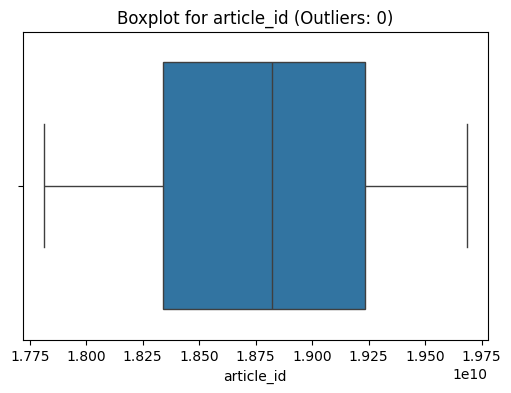

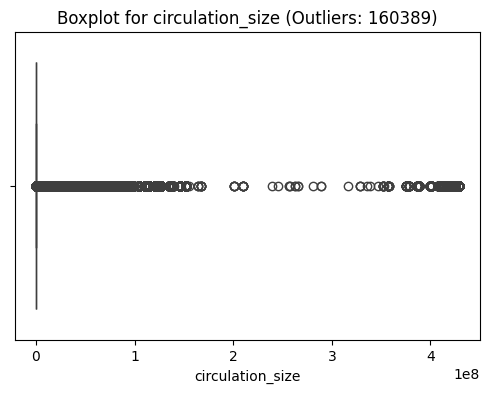

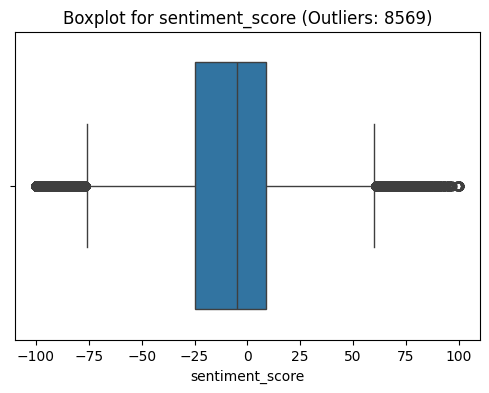

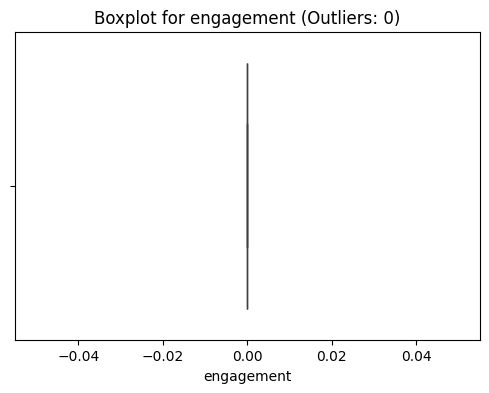

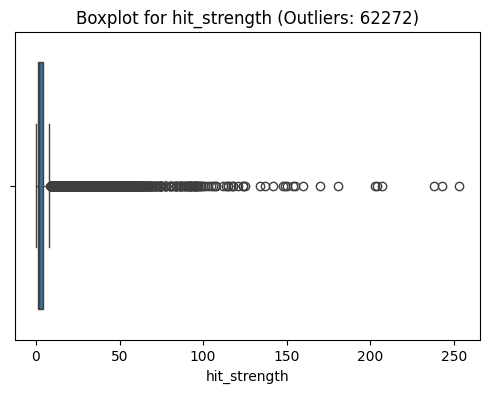

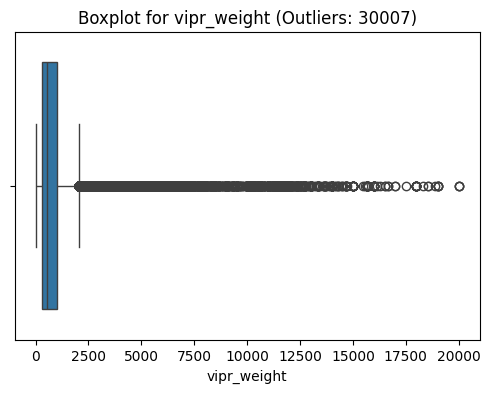

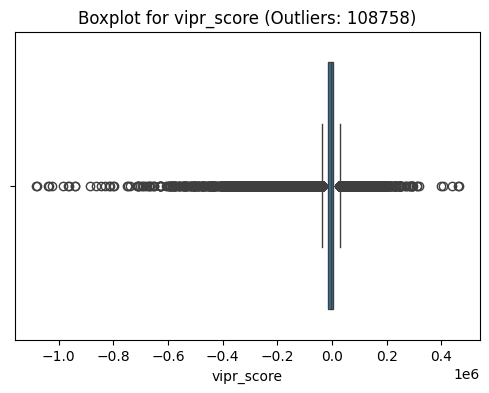

Outlier counts by column:
{'article_id': 0, 'circulation_size': 160389, 'sentiment_score': 8569, 'engagement': 0, 'hit_strength': 62272, 'vipr_weight': 30007, 'vipr_score': 108758}


In [17]:
clean_df = detect_outliers_iqr(df, numeric_cols, remove = False)

In [18]:
### remedying the outliers, doing log transformation
df_transformed = df.copy()


for col in ["vipr_weight", "hit_strength", "circulation_size"]:
    df_transformed[col + "_log"] = np.log1p(df_transformed[col])

lower = df_transformed["vipr_score"].quantile(0.01)
upper = df_transformed["vipr_score"].quantile(0.99)
df_transformed["vipr_score_clip"] = df_transformed["vipr_score"].clip(lower, upper)

print("Transformations complete. New columns created:")
print([c for c in df_transformed.columns if c.endswith("_log") or c.endswith("_clip")])

Transformations complete. New columns created:
['vipr_weight_log', 'hit_strength_log', 'circulation_size_log', 'vipr_score_clip']


## EDA

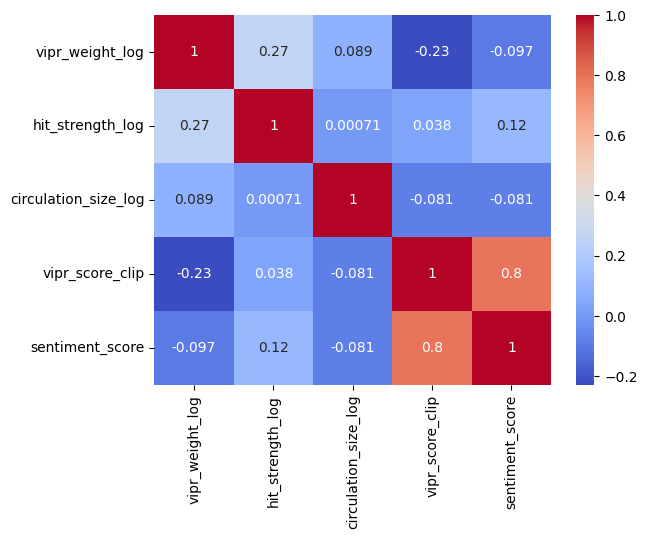

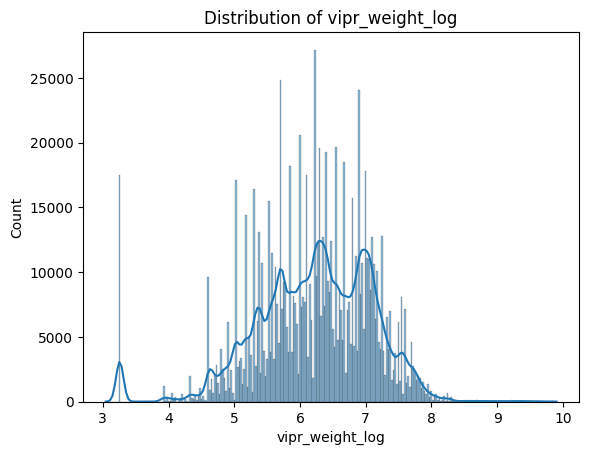

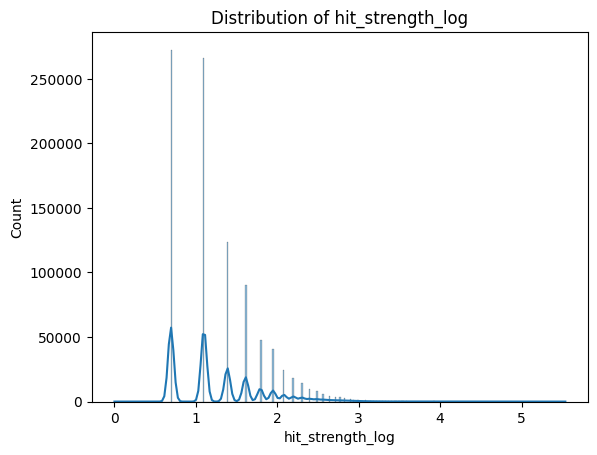

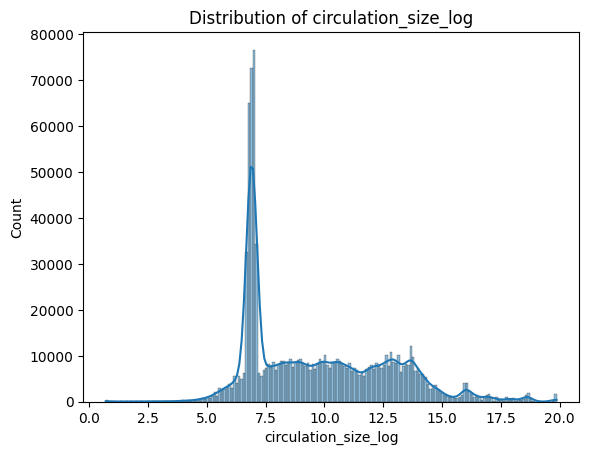

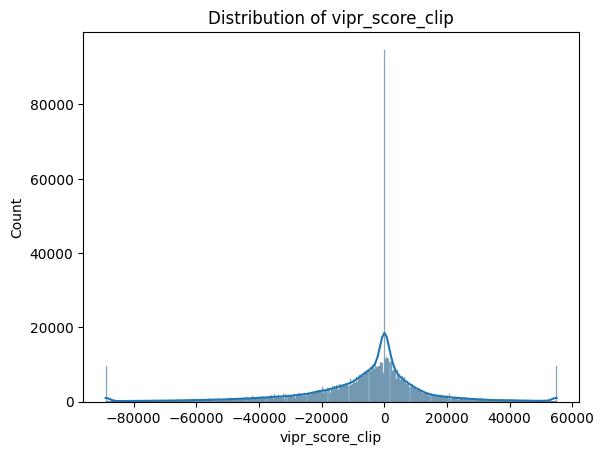

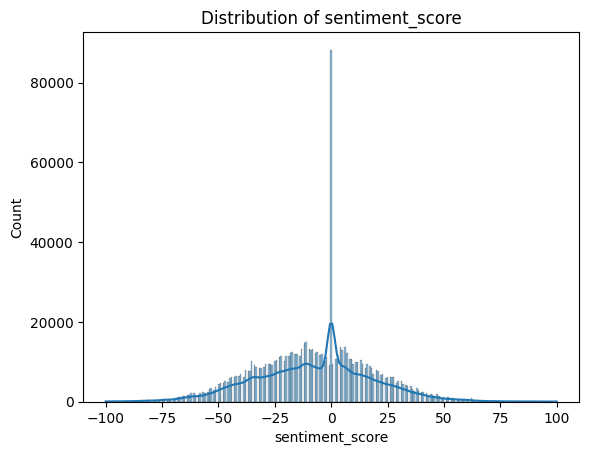

In [19]:
cols_for_corr = ["vipr_weight_log", "hit_strength_log", "circulation_size_log", "vipr_score_clip", "sentiment_score"]
sns.heatmap(df_transformed[cols_for_corr].corr(), annot=True, cmap="coolwarm")
plt.show()

for col in cols_for_corr:
    sns.histplot(df_transformed[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


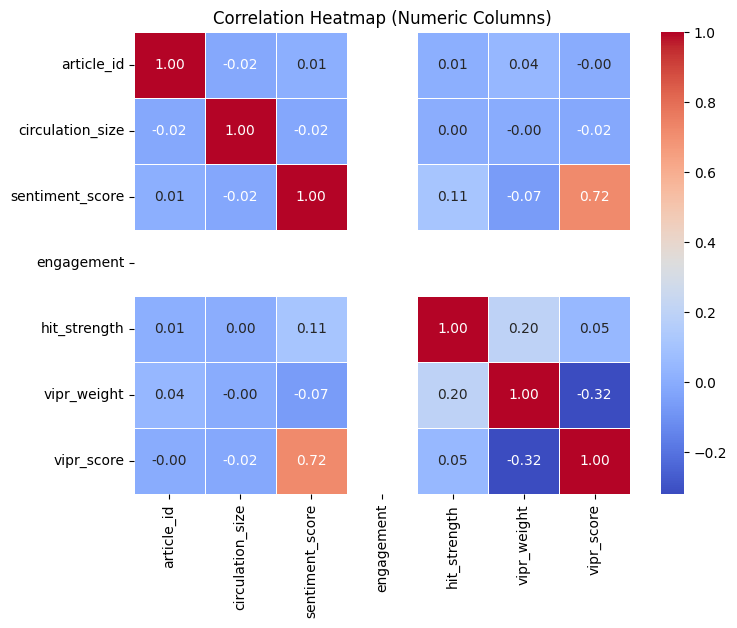

In [20]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

In [21]:
### VIPR score highly correlated to sentiment scoring

In [25]:
df_conv = df_transformed.copy()

# Ensure the transformed columns exist
required_cols = ["circulation_size_log", "vipr_weight_log", "hit_strength_log"]
missing = [c for c in required_cols if c not in df_conv.columns]
if missing:
    raise ValueError(f"Missing transformed cols: {missing}. Re-run your transform step.")

# 75th-percentile thresholds
circ_thr     = df_conv["circulation_size_log"].quantile(0.75)
weight_thr   = df_conv["vipr_weight_log"].quantile(0.75)
strength_thr = df_conv["hit_strength_log"].quantile(0.75)

# Flag = 1 if in the top quartile on all three
df_conv["conversion_proxy"] = (
    (df_conv["circulation_size_log"] >= circ_thr) &
    (df_conv["vipr_weight_log"]   >= weight_thr) &
    (df_conv["hit_strength_log"]  >= strength_thr)
).astype(int)

print("conversion_proxy distribution:")
print(df_conv["conversion_proxy"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


conversion_proxy distribution:
conversion_proxy
0    96.44%
1     3.56%
Name: proportion, dtype: object


In [26]:
count_1 = df_conv["conversion_proxy"].sum()
count_0 = (df_conv["conversion_proxy"] == 0).sum()

print(f"Articles qualifying as 1 (conversion proxy): {count_1}")
print(f"Articles qualifying as 0: {count_0}")
print(f"Percentage qualifying: {count_1 / len(df_conv) * 100:.2f}%")

Articles qualifying as 1 (conversion proxy): 33733
Articles qualifying as 0: 912528
Percentage qualifying: 3.56%


In [30]:
def eda_tables_dual(df: pd.DataFrame):
    """
    Build EDA tables for:
      - Top publications (article_count, avg_circulation)
      - Avg circulation by source type
      - EDA by channel (article_count, avg_circulation)
      - Daily article & circulation distribution
      - Monthly article & circulation distribution
      - Sentiment band EDA (distribution)
      - Sentiment score EDA (summary + by band)

    Returns:
      {
        "full": { <tables> },
        "conversion": { <tables> }  # only if 'conversion_proxy' in df
      }
    """

    def _build(sub_df: pd.DataFrame):
        out = {}

        # ---- time keys
        day = sub_df["load_date"].dt.date
        month = sub_df["load_date"].dt.to_period("M").dt.to_timestamp()

        # ---- 1) Top publications
        out["top_publications"] = (
            sub_df.groupby("publication_name", dropna=False)
                  .agg(article_count=("article_id", "count"),
                       avg_circulation=("circulation_size", "mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .head(25)
                  .reset_index()
        )

        # ---- 2) Avg circulation by source type
        st_col = "source_type_name" if "source_type_name" in sub_df.columns else "source_type"
        out["avg_circulation_by_source_type"] = (
            sub_df.groupby(st_col, dropna=False)
                  .agg(avg_circulation=("circulation_size","mean"),
                       median_circulation=("circulation_size","median"),
                       article_count=("article_id","count"))
                  .sort_values("avg_circulation", ascending=False)
                  .reset_index()
        )

        # ---- 3) EDA by channel (count + avg circ)
        out["by_channel"] = (
            sub_df.groupby("channel_name", dropna=False)
                  .agg(article_count=("article_id","count"),
                       avg_circulation=("circulation_size","mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .reset_index()
        )

        # ---- 4) Daily distribution (articles + total circulation)
        out["daily_distribution"] = (
            sub_df.assign(DAY=day)
                  .groupby("DAY", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("DAY")
        )

        # ---- 5) Monthly distribution (articles + total circulation)
        out["monthly_distribution"] = (
            sub_df.assign(MONTH=month)
                  .groupby("MONTH", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("MONTH")
        )

        # ---- 6) Sentiment band EDA
        out["sentiment_band_distribution"] = (
            sub_df["sentiment_band"].value_counts(dropna=False)
                .rename_axis("sentiment_band")
                .reset_index(name="count")
        )
        # with percentages
        total_rows = len(sub_df)
        if total_rows > 0:
            out["sentiment_band_distribution"]["pct"] = (
                out["sentiment_band_distribution"]["count"] / total_rows * 100
            ).round(2)

        # ---- 7) Sentiment score EDA
        # overall summary
        if "sentiment_score" in sub_df.columns:
            out["sentiment_score_summary"] = (
                sub_df["sentiment_score"].describe().to_frame("value")
            )
            # by band
            out["sentiment_score_by_band"] = (
                sub_df.groupby("sentiment_band", dropna=False)["sentiment_score"]
                      .agg(mean="mean", median="median", std="std", count="count")
                      .reset_index()
                      .sort_values("mean", ascending=False)
            )
        else:
            out["sentiment_score_summary"] = pd.DataFrame()
            out["sentiment_score_by_band"] = pd.DataFrame()

        return out

    results = {"full": _build(df)}

    # add conversion subset if available
    if "conversion_proxy" in df.columns:
        results["conversion"] = _build(df[df["conversion_proxy"] == 1].copy())

    return results


In [31]:
eda_tables_dual(df)["full"]

{'top_publications':                                   publication_name  article_count  \
 0                                      Head Topics          15225   
 1   Multidisciplinary Digital Publishing Institute           7526   
 2                                          Archyde           4182   
 3                                       Archynetys           3535   
 4                                           Medium           3315   
 5                                        ReliefWeb           2873   
 6                                       News Break           2616   
 7                                   Medical Xpress           2575   
 8                                       World News           2549   
 9                                              MSN           2399   
 10                                             AOL           2365   
 11                                            NCBI           2358   
 12                                     Newsy Today           2153   


In [32]:
tables_dual = eda_tables_dual(df_conv)
tables_dual["full"]["by_channel"].head()

,channel_name,article_count,avg_circulation
0,Web,725517,2.812122e+06
1,Broadcast,179186,2.949601e+05
2,Social,40232,1.192877e+06
3,Print,1323,6.316273e+05
4,Unknown,3,1.613333e+02


In [33]:
tables_dual["conversion"]["by_channel"].head(5)

,channel_name,article_count,avg_circulation
0,Web,32645,6.334917e+06
1,Social,931,1.572538e+07
2,Broadcast,119,1.536062e+06
3,Print,38,8.321504e+06


In [34]:
tables_dual["conversion"]["sentiment_score_by_band"]

,sentiment_band,mean,median,std,count
2,Positive,29.049434,25.0,12.415907,3621
1,Neutral,-2.781047,-2.0,7.359490,17707
0,Negative,-32.156872,-29.0,13.958774,12405


In [37]:
def eda_visuals_matplotlib(df: pd.DataFrame, title_prefix="Dataset"):
    # ---- 0) small helpers ----
    def barh_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(10, 6))
        s = s.sort_values(ascending=True)
        plt.barh(s.index.astype(str), s.values)
        plt.title(title_prefix + ": " + title)
        plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.tight_layout(); plt.show()

    def barh_from_df(df_in: pd.DataFrame, cat_col: str, val_col: str, title: str, xlabel: str, ylabel: str, top_n=15):
        if df_in.empty or cat_col not in df_in or val_col not in df_in: return
        dd = df_in[[cat_col, val_col]].dropna()
        dd = dd.groupby(cat_col)[val_col].mean().sort_values(ascending=False).head(top_n)
        barh_from_series(dd, title, xlabel, ylabel)

    def line_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.plot(s.index, s.values)
        plt.title(title_prefix + ": " + title)
        plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout(); plt.show()

    def bar_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.bar(s.index.astype(str), s.values)
        plt.title(title_prefix + ": " + title)
        plt.xlabel(xlabel); plt.ylabel(ylabel)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout(); plt.show()

    def hist1(col: str, bins=40, logscale=False, title_suffix=""):
        if col not in df: return
        x = pd.to_numeric(df[col], errors="coerce").dropna()
        if x.empty: return
        plt.figure(figsize=(8, 5))
        plt.hist(x.values, bins=bins)
        if logscale:
            plt.yscale("log")
        ttl = f"{title_prefix}: Distribution of {col}"
        if title_suffix: ttl += f" ({title_suffix})"
        plt.title(ttl)
        plt.xlabel(col); plt.ylabel("Count")
        plt.tight_layout(); plt.show()

    # ---- 1) Top publications by article count ----
    if "publication_name" in df and "article_id" in df:
        top_pubs = df["publication_name"].value_counts().head(15)
        barh_from_series(top_pubs, "Top Publications by Article Count", "Article Count", "Publication")

    # ---- 2) Average circulation by source type ----
    st_col = "source_type_name" if "source_type_name" in df.columns else ("source_type" if "source_type" in df.columns else None)
    if st_col and "circulation_size" in df:
        barh_from_df(df, st_col, "circulation_size", "Average Circulation by Source Type", "Average Circulation", "Source Type", top_n=20)

    # ---- 3) EDA by channel (article count) ----
    if "channel_name" in df:
        top_channels = df["channel_name"].value_counts().head(15)
        barh_from_series(top_channels, "Top Channels by Article Count", "Article Count", "Channel")

    # ---- 4) Daily article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        # ensure datetime
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_counts = df.assign(_day=ld.dt.date).groupby("_day")["article_id"].count()
        line_from_series(daily_counts, "Daily Article Count", "Date", "Articles")

    # ---- 5) Monthly article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_counts = df.assign(_month=month).groupby("_month")["article_id"].count()
        bar_from_series(monthly_counts, "Monthly Article Count", "Month", "Articles")

    # ---- 6) Daily circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_circ = df.assign(_day=ld.dt.date).groupby("_day")["circulation_size"].sum()
        line_from_series(daily_circ, "Daily Circulation (Sum)", "Date", "Total Circulation")

    # ---- 7) Monthly circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_circ = df.assign(_month=month).groupby("_month")["circulation_size"].sum()
        bar_from_series(monthly_circ, "Monthly Circulation (Sum)", "Month", "Total Circulation")

    # ---- 8) Sentiment band distribution ----
    if "sentiment_band" in df:
        band_counts = df["sentiment_band"].value_counts()
        bar_from_series(band_counts, "Sentiment Band Distribution", "Count", "Sentiment Band")

    # ---- 9) Sentiment score distribution ----
    if "sentiment_score" in df:
        hist1("sentiment_score", bins=50, title_suffix="linear scale")

    for col in ["vipr_weight_log", "hit_strength_log", "circulation_size_log"]:
        if col in df.columns:
            hist1(col, bins=50, title_suffix="log-transformed")

    # Clipped vipr score
    if "vipr_score_clip" in df.columns:
        hist1("vipr_score_clip", bins=60, title_suffix="clipped (1st–99th pct)")

    # Optional: relationship between sentiment_score and vipr_score_clip
    if "vipr_score_clip" in df.columns and "sentiment_score" in df.columns:
        x = pd.to_numeric(df["vipr_score_clip"], errors="coerce")
        y = pd.to_numeric(df["sentiment_score"], errors="coerce")
        m = (~x.isna()) & (~y.isna())
        if m.any():
            plt.figure(figsize=(8, 6))
            plt.scatter(x[m].values, y[m].values, alpha=0.15, s=8)
            plt.title(title_prefix + ": VIPR Score (clipped) vs Sentiment Score")
            plt.xlabel("vipr_score_clip"); plt.ylabel("sentiment_score")
            plt.tight_layout(); plt.show()

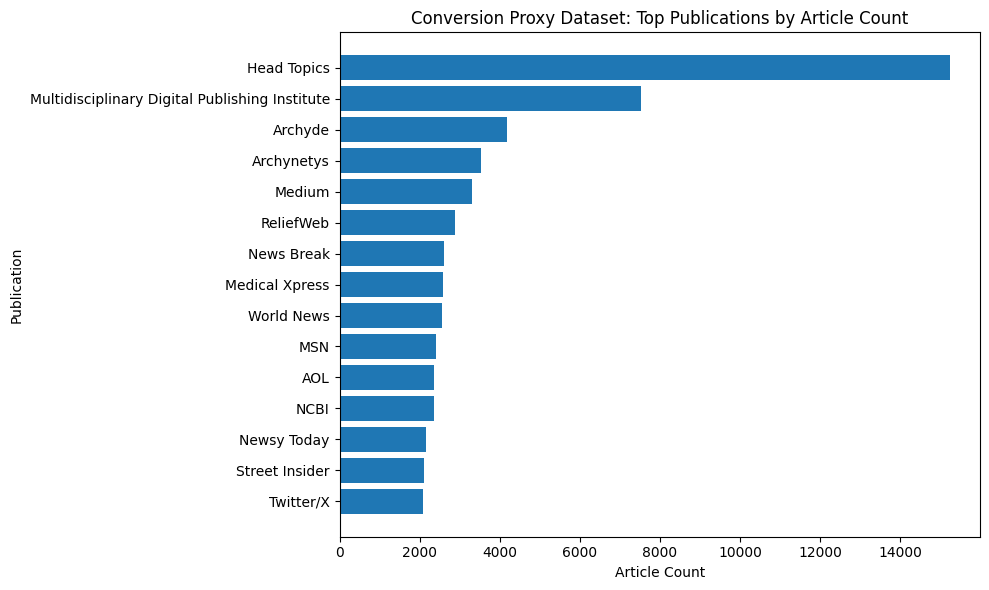

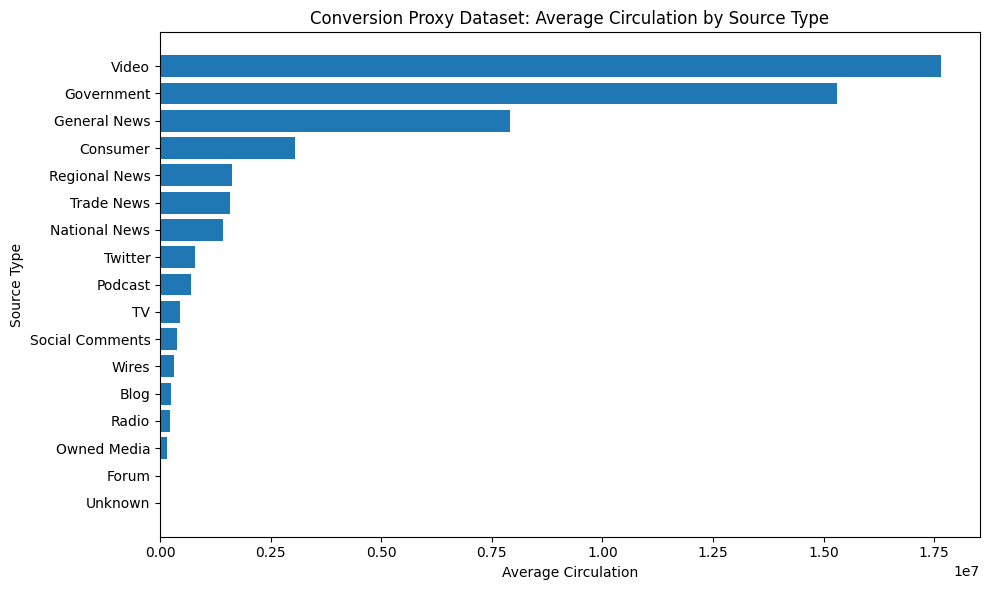

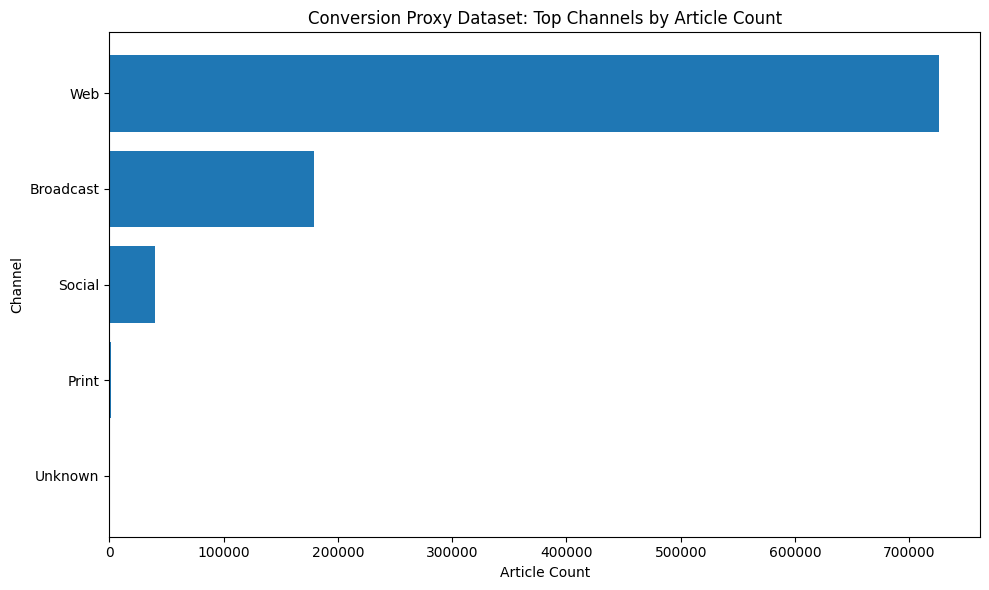

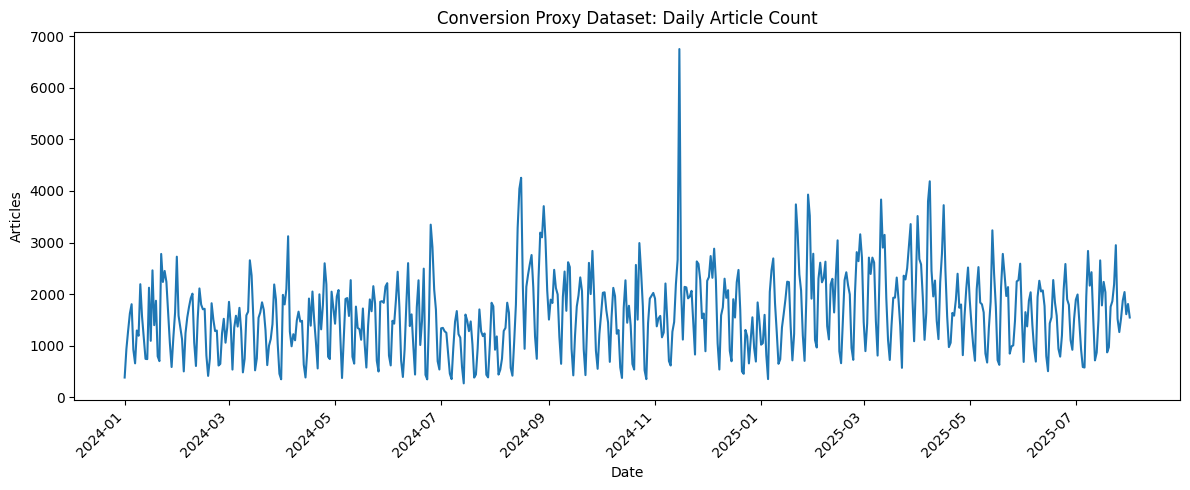

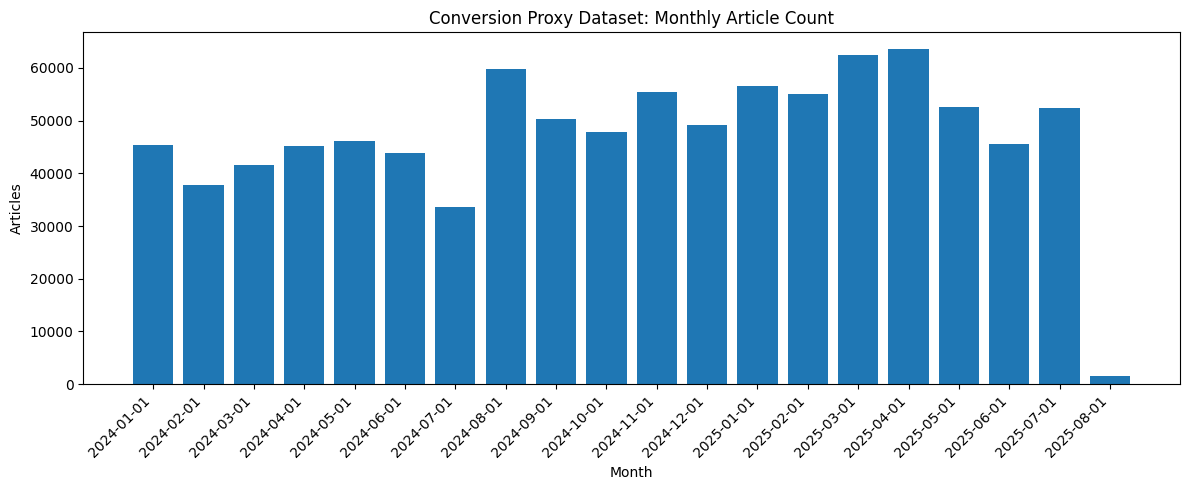

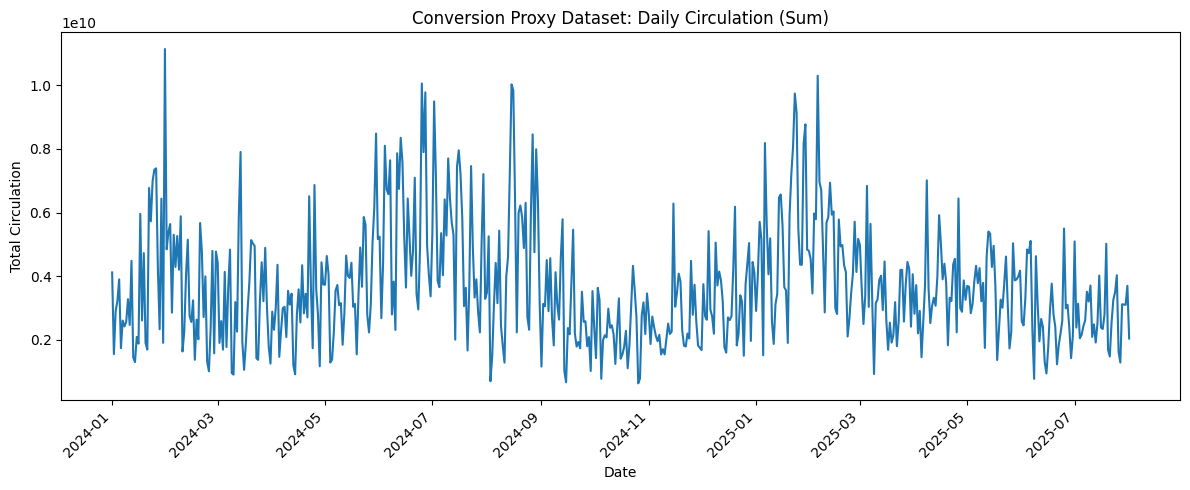

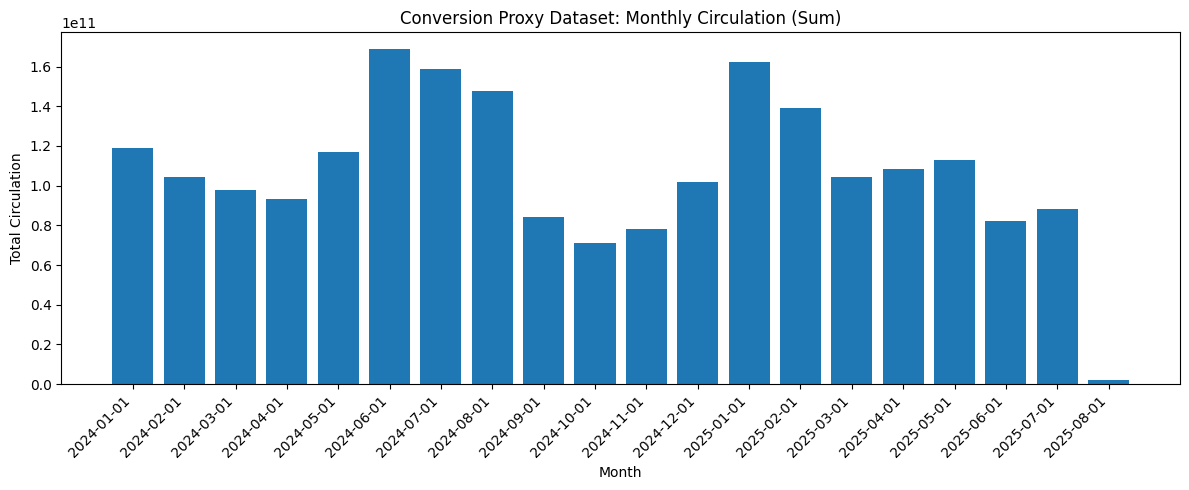

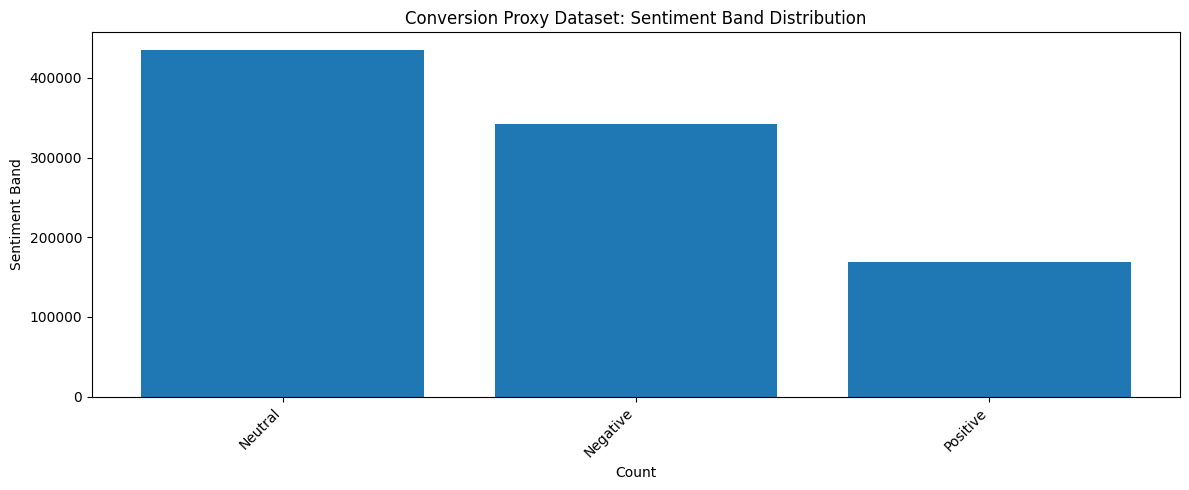

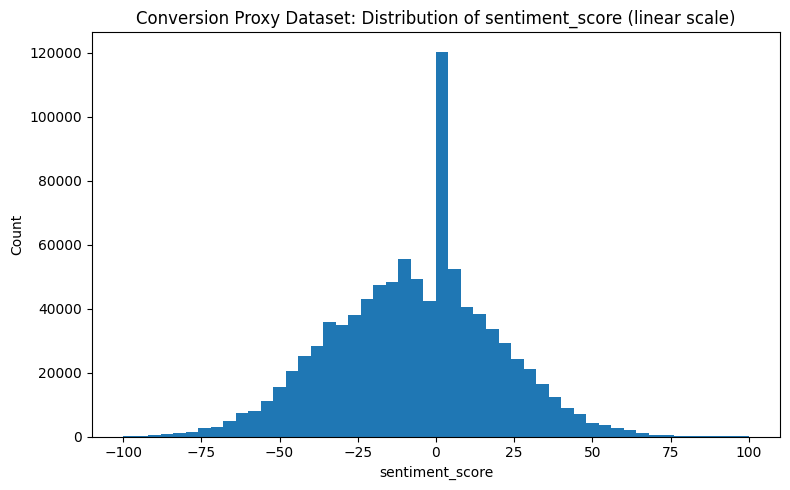

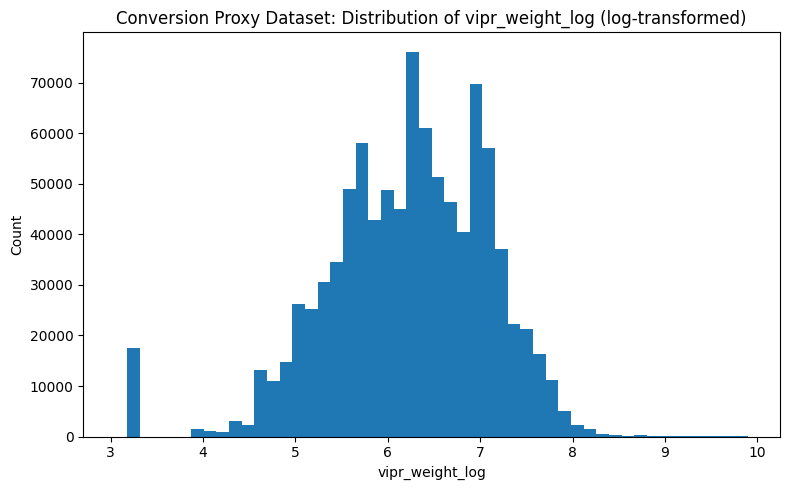

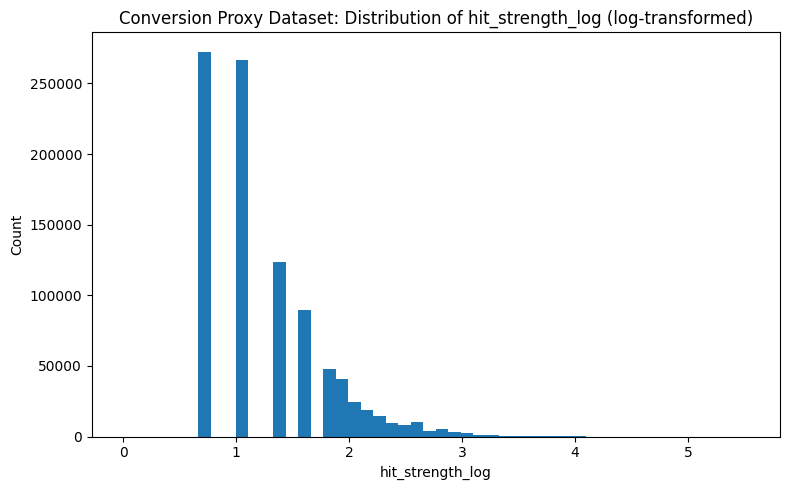

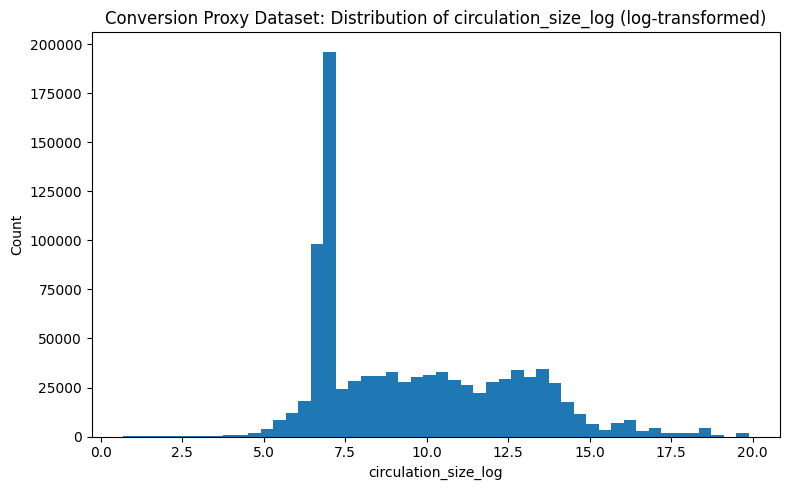

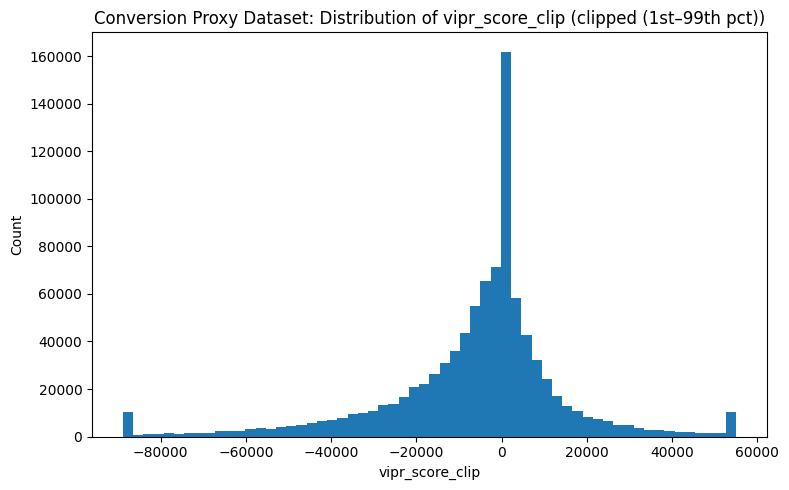

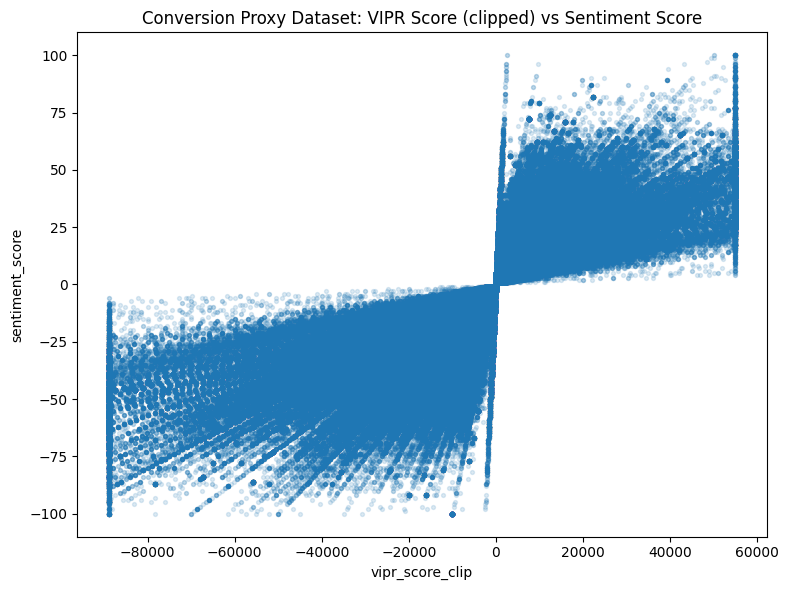

In [38]:
eda_visuals_matplotlib(df_conv, title_prefix="Conversion Proxy Dataset")

## Network Analysis EDA

In [39]:
def build_bipartite_source_tag(
    df: pd.DataFrame,
    source_col: str = "source_type_name",   
    tag_col: str = "tag_name",
    min_weight: int = 2                     
) -> nx.Graph:
    # Aggregate counts of (source_type, tag)
    counts = (df.groupby([source_col, tag_col])
                .size()
                .reset_index(name="weight"))
    # Filter weak edges
    counts = counts[counts["weight"] >= min_weight]

    B = nx.Graph()
    # Left partition: source types
    B.add_nodes_from(counts[source_col].unique(), bipartite=0)
    # Right partition: tags
    B.add_nodes_from(counts[tag_col].unique(), bipartite=1)
    # Weighted edges
    B.add_weighted_edges_from(counts[[source_col, tag_col, "weight"]].itertuples(index=False, name=None))
    return B, counts

def visualize_top_component(
    G: nx.Graph,
    title: str = "SourceType ↔ Tag (bipartite, clean view)",
    top_n: int = 80,           # keep top-N nodes by degree for readability
    label_top: int = 20,       # label top-N nodes by degree
    edge_keep_pct: int = 70    # keep top X% edges by weight within subgraph
):
    if G.number_of_nodes() == 0:
        print("Graph is empty."); return

    # pick top-N by degree
    deg = dict(G.degree())
    nodes = [n for n,_ in sorted(deg.items(), key=lambda x: x[1], reverse=True)[:top_n]]
    H = G.subgraph(nodes).copy()
    if H.number_of_edges() == 0:
        print("No edges in subgraph."); return

    # largest connected component
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()
    if H.number_of_edges() == 0:
        print("No edges after component filter."); return

    # prune weak edges by percentile
    weights = np.array([H[u][v].get("weight", 1) for u, v in H.edges()])
    thr = np.percentile(weights, 100 - edge_keep_pct)
    H.remove_edges_from([(u, v) for u, v in H.edges() if H[u][v].get("weight", 1) < thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return

    # layout & draw (matplotlib only)
    pos = nx.spring_layout(H, seed=42, iterations=200)
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    plt.figure(figsize=(11, 9))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.45)
    nx.draw_networkx_nodes(H, pos, node_size=320)
    # label top nodes by degree
    top_labels = set([n for n,_ in sorted(dict(H.degree()).items(), key=lambda x: x[1], reverse=True)[:label_top]])
    labels = {n: n for n in H.nodes() if n in top_labels}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8)
    plt.title(title)
    plt.axis("off"); plt.tight_layout(); plt.show()

Bipartite graph: 23 nodes, 76 edges


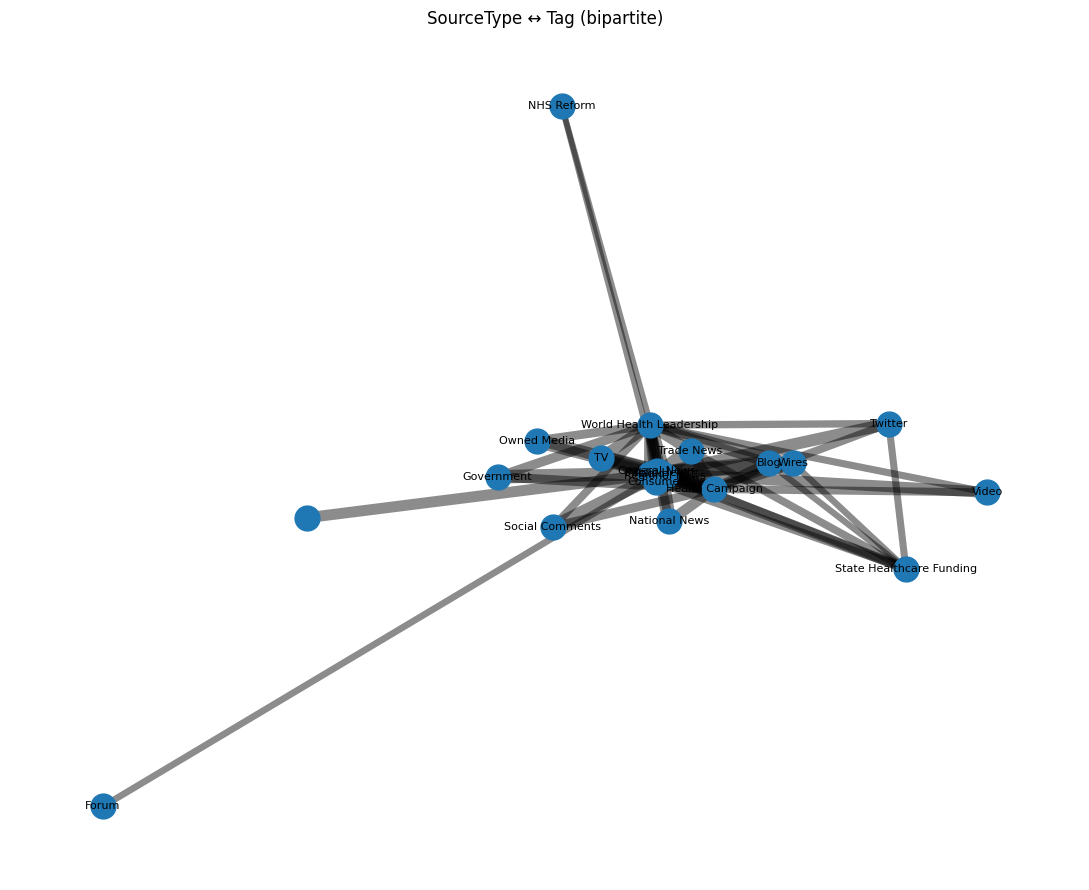

,source_type_name,tag_name,weight
46,Regional News,Public Health,375212
40,Radio,Public Health,114488
17,General News,Public Health,89244
8,Consumer,Public Health,86056
62,Trade News,Public Health,58470
57,TV,Public Health,51776
43,Regional News,Health Campaign,27052
3,Blog,Public Health,25113
77,Wires,Public Health,15486
26,National News,Public Health,15447


In [40]:
B_src_tag, edge_table = build_bipartite_source_tag(df_transformed, source_col="source_type_name", tag_col="tag_name", min_weight=2)
print(f"Bipartite graph: {B_src_tag.number_of_nodes():,} nodes, {B_src_tag.number_of_edges():,} edges")
visualize_top_component(B_src_tag, title="SourceType ↔ Tag (bipartite)")

# Optional: inspect the strongest SourceType–Tag pairs
edge_table.sort_values("weight", ascending=False).head(20)

SourceType–SourceType: 17 nodes, 136 edges


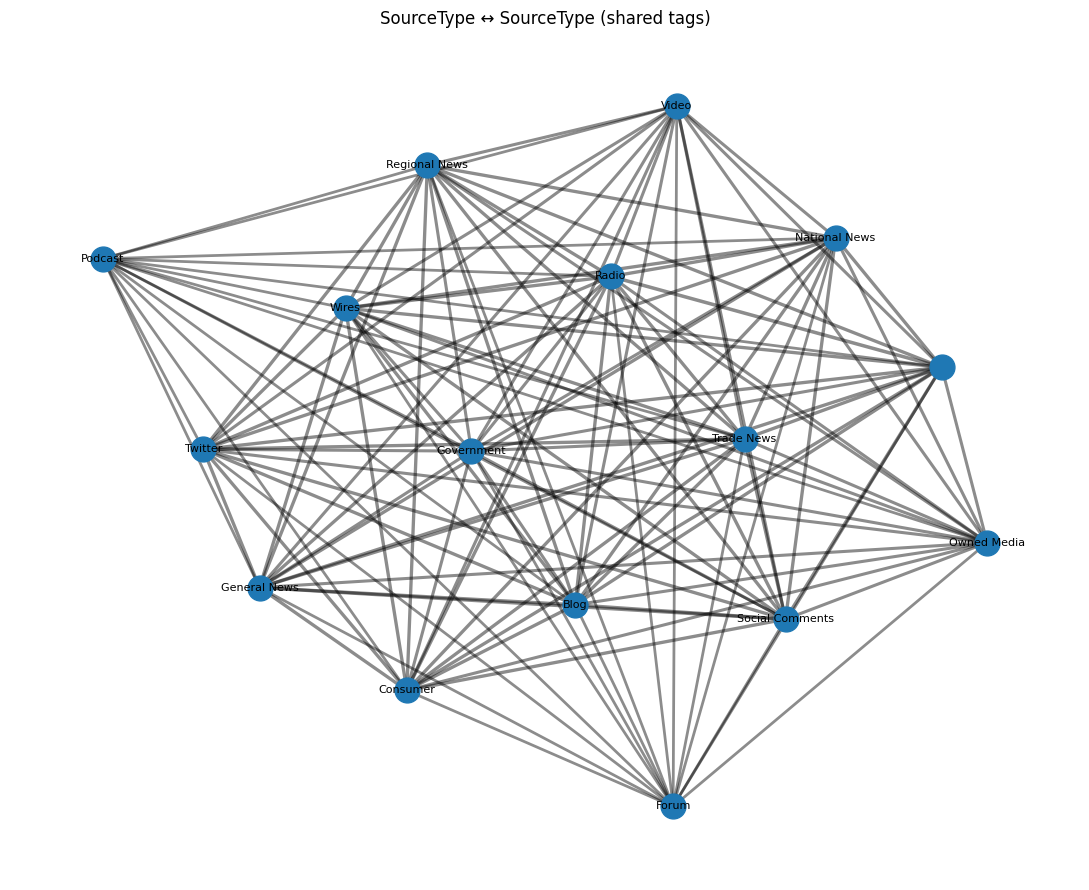

In [41]:
src_nodes = {n for n, d in B_src_tag.nodes(data=True) if d.get("bipartite") == 0}

# Weighted projection
G_src = bipartite.weighted_projected_graph(B_src_tag, src_nodes)
print(f"SourceType–SourceType: {G_src.number_of_nodes():,} nodes, {G_src.number_of_edges():,} edges")

# Visualize a clean slice
visualize_top_component(G_src, title="SourceType ↔ SourceType (shared tags)", top_n=40, label_top=15, edge_keep_pct=70)

### Keyword Network Analysis

In [42]:
CUSTOM_STOP = {
    "said","say","says","told","new","year","years","today","week","weeks",
    "people","one","two","also","like","make","made","time","according",
    "world","health","public","report","reports","reported","media"
}

def clean_text_series(s: pd.Series) -> pd.Series:
    s = s.fillna("")
    s = s.str.replace(r"http\S+|\S+@\S+|#\w+|@\w+", " ", regex=True)
    s = s.str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
    return s

def build_dtm_phrases(texts: pd.Series,
                      min_df=20, max_df=0.5,
                      ngram_range=(2,3),
                      max_features=20000):
    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9]+\b",
        min_df=min_df, max_df=max_df,
        ngram_range=ngram_range,
        max_features=max_features
    )
    X = vectorizer.fit_transform(texts)
    vocab = np.array(vectorizer.get_feature_names_out())
    # remove custom stopwords (drop rows containing any stopword token)
    mask = np.array([not any(tok in CUSTOM_STOP for tok in v.split()) for v in vocab])
    X = X[:, mask]; vocab = vocab[mask]
    return X.tocsr(), vocab

def cooccurrence(X: csr_matrix, top_k_terms=8000):
    if top_k_terms and X.shape[1] > top_k_terms:
        dfreq = np.asarray(X.astype(bool).sum(axis=0)).ravel()
        keep = np.argsort(-dfreq)[:top_k_terms]
        X = X[:, keep]
    C = (X.T @ (X>0)).tocsr()   # binary co-occurrence
    C.setdiag(0); C.eliminate_zeros()
    return C

def graph_from_C(C: csr_matrix, vocab: np.ndarray, min_weight=4, max_edges=120_000):
    r,c = C.nonzero(); w = np.asarray(C[r,c]).ravel().astype(int)
    m = (r<c) & (w>=min_weight)
    r,c,w = r[m], c[m], w[m]
    if len(w) > max_edges:
        idx = np.argsort(-w)[:max_edges]; r,c,w = r[idx], c[idx], w[idx]
    G = nx.Graph(); terms = vocab
    for i,j,wt in zip(r,c,w): G.add_edge(terms[i], terms[j], weight=int(wt))
    return G

def visualize_clean(G: nx.Graph, title="Keyword Network", top_n=80, label_top=12,
                    edge_keep_pct=70, drop_hub_pct=2):
    if G.number_of_nodes()==0: 
        print("Empty graph"); return
    # drop the top hub nodes (by degree) to avoid starburst
    deg = dict(G.degree()); hubs = int(len(deg)*(drop_hub_pct/100))
    if hubs>0:
        for n,_ in sorted(deg.items(), key=lambda x:x[1], reverse=True)[:hubs]:
            G.remove_node(n)
    if G.number_of_nodes()==0 or G.number_of_edges()==0:
        print("Graph empty after hub drop."); return

    # focus on top_n by degree
    deg = dict(G.degree())
    nodes = [n for n,_ in sorted(deg.items(), key=lambda x:x[1], reverse=True)[:top_n]]
    H = G.subgraph(nodes).copy()
    if H.number_of_edges()==0: print("No edges."); return

    # largest component + prune light edges
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()
    eW = np.array([H[u][v].get("weight",1) for u,v in H.edges()])
    thr = np.percentile(eW, 100-edge_keep_pct)
    H.remove_edges_from([(u,v) for u,v in H.edges() if H[u][v].get("weight",1) < thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n)==0])

    pos = nx.spring_layout(H, seed=42, iterations=300)
    widths = [0.6 + np.log1p(H[u][v]["weight"]) for u,v in H.edges()]
    sizes  = [400 + 20*H.degree(n) for n in H.nodes()]

    plt.figure(figsize=(11,9))
    nx.draw_networkx_edges(H, pos, width=widths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=sizes)
    top_labels = {n:n for n,_ in sorted(dict(H.degree()).items(), key=lambda x:x[1], reverse=True)[:label_top]}
    nx.draw_networkx_labels(H, pos, labels=top_labels, font_size=8)
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

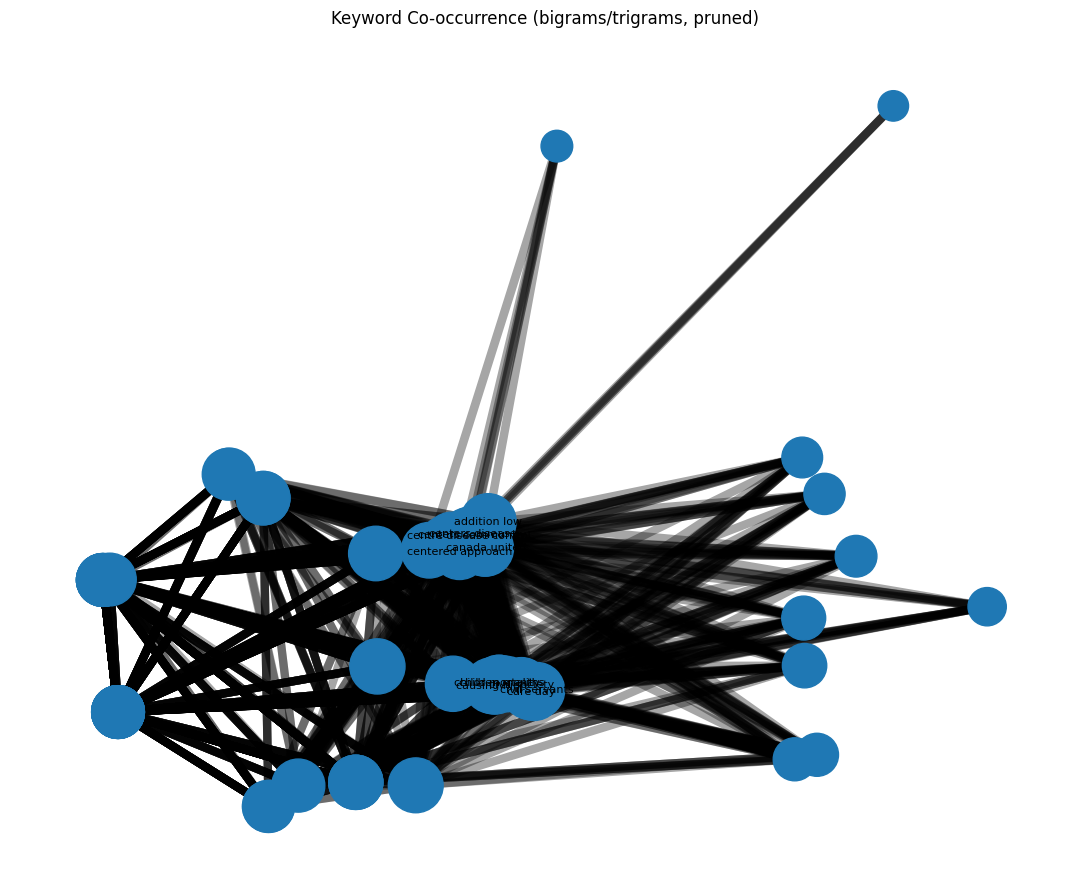

In [43]:
texts = clean_text_series(df_transformed["article_body"])

# Try stricter thresholds to reduce clutter; tweak as needed
X, vocab = build_dtm_phrases(texts.sample(50_000, random_state=42),   # adjust n for your RAM
                             min_df=25, max_df=0.4, ngram_range=(2,3), max_features=20000)
C = cooccurrence(X, top_k_terms=8000)
G = graph_from_C(C, vocab, min_weight=5, max_edges=80_000)
visualize_clean(G, title="Keyword Co-occurrence (bigrams/trigrams, pruned)",
                top_n=70, label_top=12, edge_keep_pct=75, drop_hub_pct=3)